In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/spotify-2023.csv', encoding='latin-1')

print(f"Loaded {len(df)} songs")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Loaded 953 songs

Columns: ['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

First few rows:


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

Total missing: 145


In [3]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['key'])

df_clean['streams'] = pd.to_numeric(df_clean['streams'], errors='coerce')
df_clean = df_clean.dropna(subset=['streams'])

df_clean = df_clean[df_clean['streams'] > 0]

df_clean['decade'] = (df_clean['released_year'] // 10) * 10

df_clean.to_csv('../data/processed/cleaned_spotify_data.csv', index=False)

print(f"Cleaned data saved!")
print(f"Original: {len(df)} songs")
print(f"Cleaned: {len(df_clean)} songs")
print(f"Removed: {len(df) - len(df_clean)} songs")

Cleaned data saved!
Original: 953 songs
Cleaned: 857 songs
Removed: 96 songs


Top 10 Most Streamed Songs:
                                        track_name  \
55                                 Blinding Lights   
179                                   Shape of You   
86                               Someone You Loved   
620                                   Dance Monkey   
41   Sunflower - Spider-Man: Into the Spider-Verse   
162                                      One Dance   
84                       STAY (with Justin Bieber)   
140                                       Believer   
725                                         Closer   
48                                         Starboy   

                   artist(s)_name       streams  
55                     The Weeknd  3.703895e+09  
179                    Ed Sheeran  3.562544e+09  
86                  Lewis Capaldi  2.887242e+09  
620                   Tones and I  2.864792e+09  
41          Post Malone, Swae Lee  2.808097e+09  
162           Drake, WizKid, Kyla  2.713922e+09  
84   Justin Bieber, The Kid

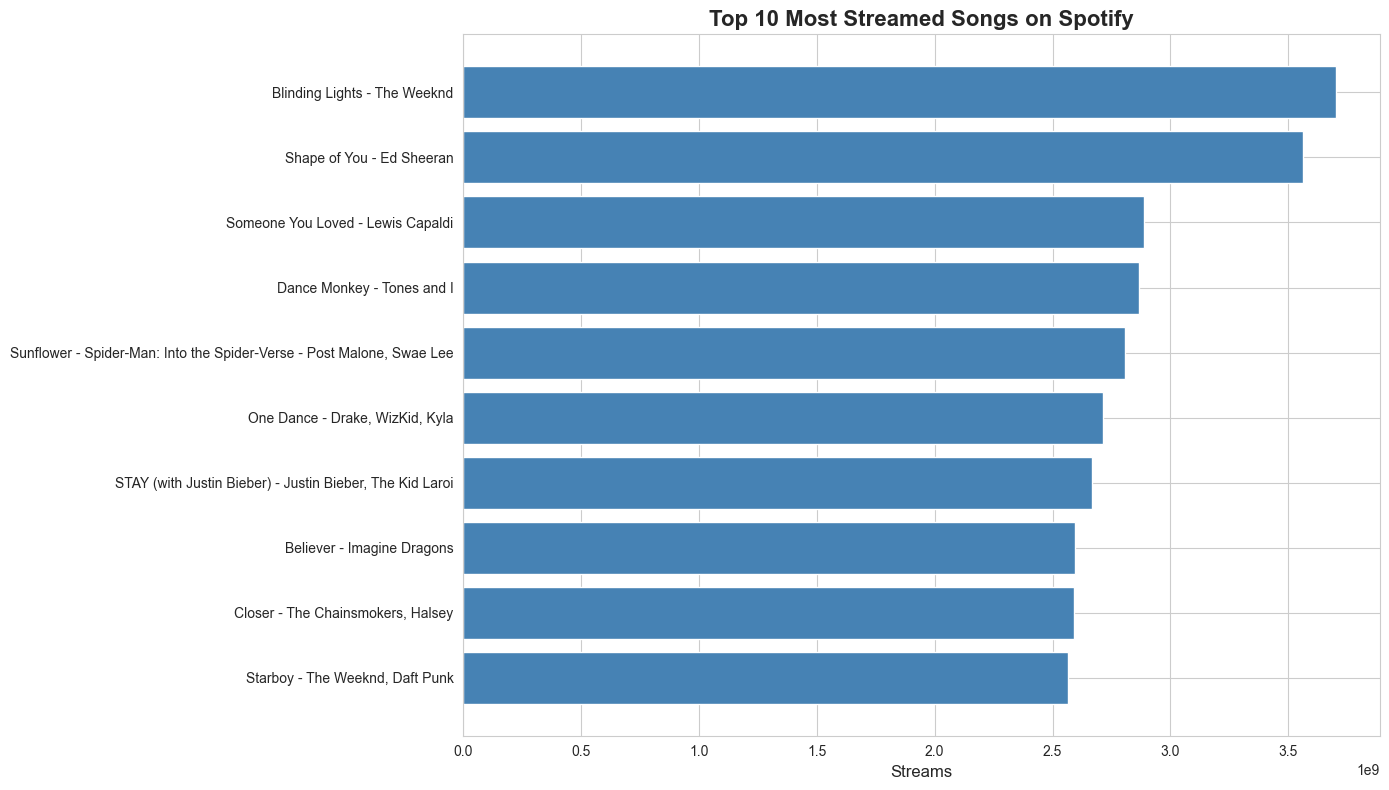

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Top 10 Most Streamed Songs:")
top_10 = df_clean.nlargest(10, 'streams')[['track_name', 'artist(s)_name', 'streams']]
print(top_10)

plt.figure(figsize=(14, 8))
plt.barh(range(len(top_10)), top_10['streams'], color='steelblue')
plt.yticks(range(len(top_10)), [f"{row['track_name']} - {row['artist(s)_name']}" for _, row in top_10.iterrows()])
plt.xlabel('Streams', fontsize=12)
plt.title('Top 10 Most Streamed Songs on Spotify', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

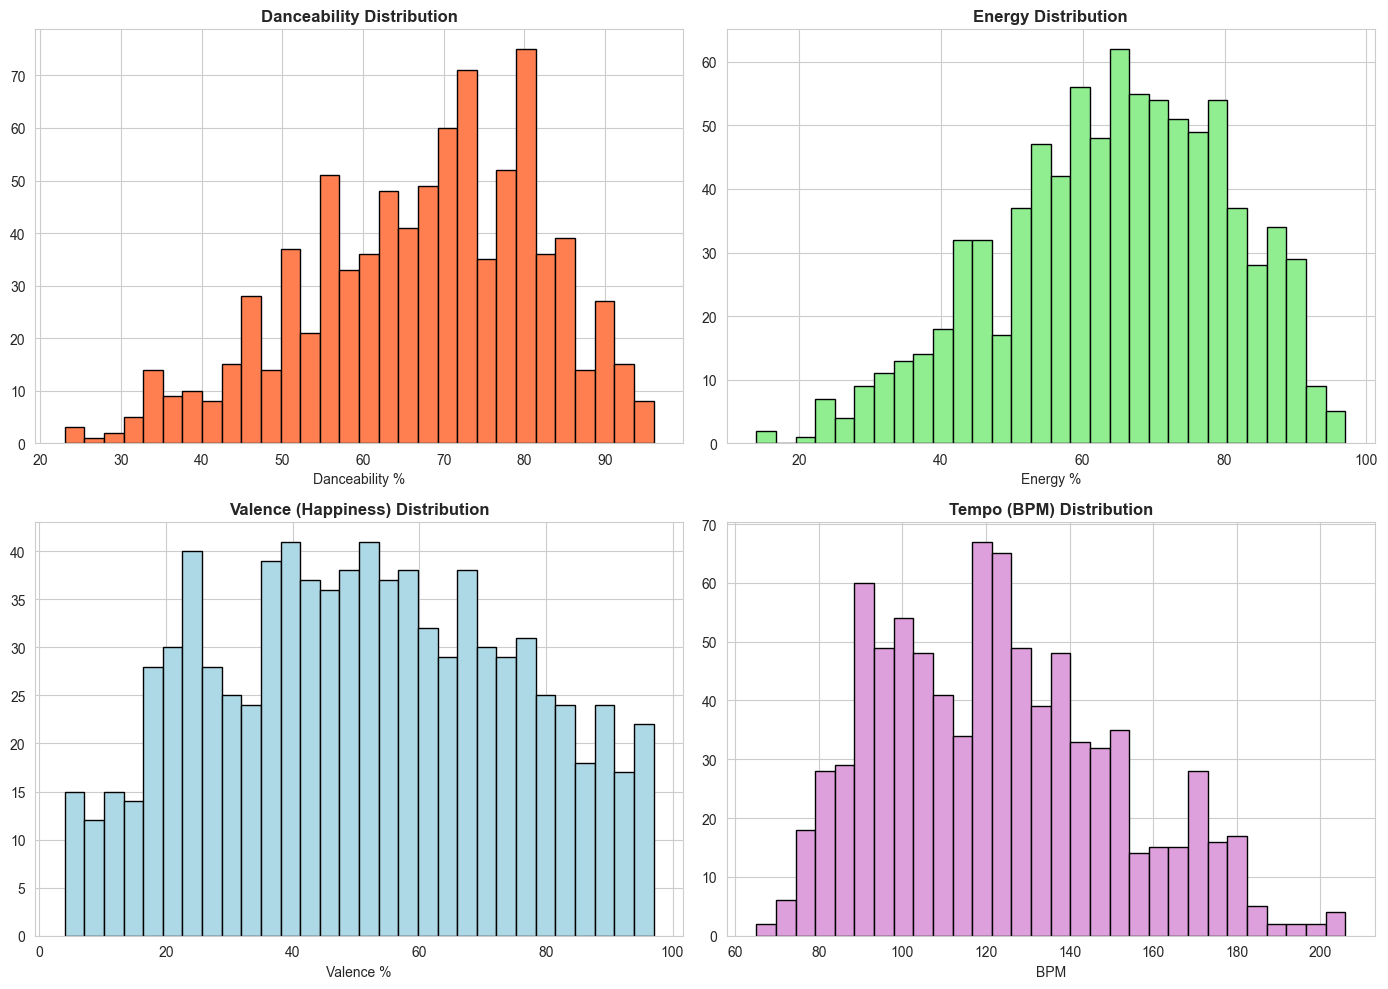

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_clean['danceability_%'], bins=30, color='coral', edgecolor='black')
axes[0, 0].set_title('Danceability Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Danceability %')

axes[0, 1].hist(df_clean['energy_%'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Energy Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Energy %')

axes[1, 0].hist(df_clean['valence_%'], bins=30, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Valence (Happiness) Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Valence %')

axes[1, 1].hist(df_clean['bpm'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Tempo (BPM) Distribution', fontweight='bold')
axes[1, 1].set_xlabel('BPM')

plt.tight_layout()
plt.show()

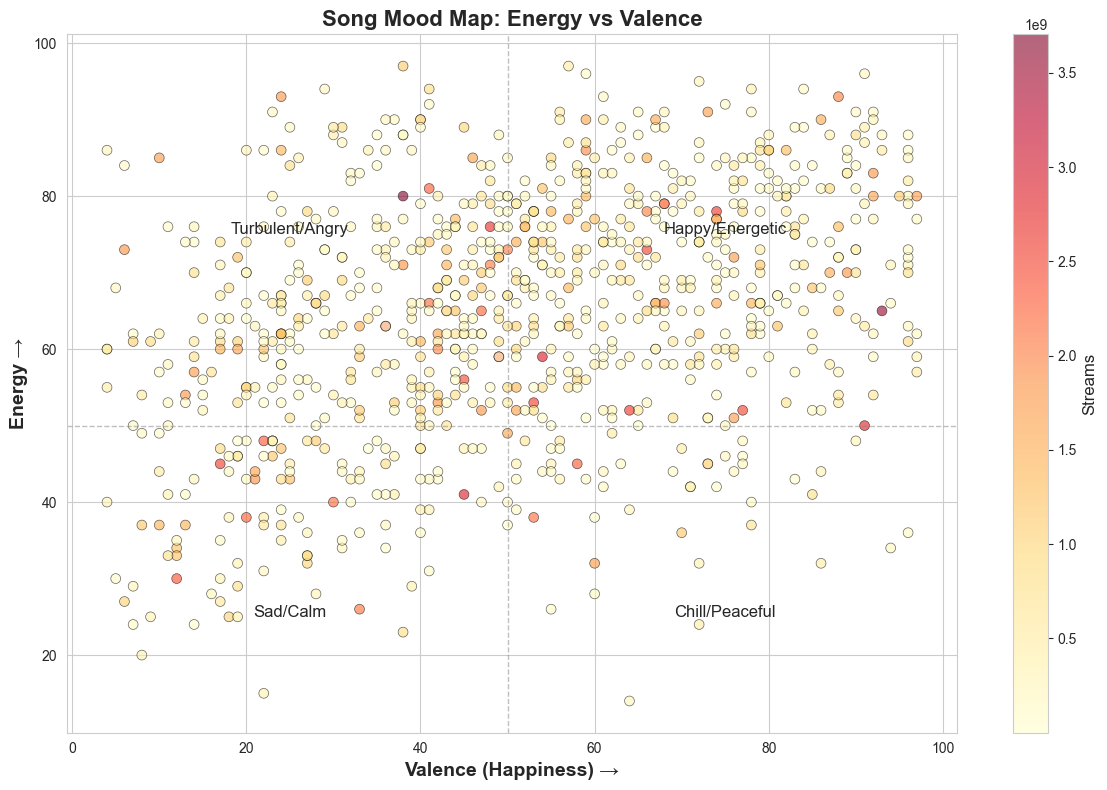

In [6]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df_clean['valence_%'], df_clean['energy_%'], 
                     c=df_clean['streams'], cmap='YlOrRd', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.text(25, 75, 'Turbulent/Angry', fontsize=12, ha='center')
plt.text(75, 75, 'Happy/Energetic', fontsize=12, ha='center')
plt.text(25, 25, 'Sad/Calm', fontsize=12, ha='center')
plt.text(75, 25, 'Chill/Peaceful', fontsize=12, ha='center')

plt.xlabel('Valence (Happiness) →', fontsize=14, fontweight='bold')
plt.ylabel('Energy →', fontsize=14, fontweight='bold')
plt.title('Song Mood Map: Energy vs Valence', fontsize=16, fontweight='bold')

cbar = plt.colorbar(scatter)
cbar.set_label('Streams', fontsize=12)

plt.tight_layout()
plt.show()

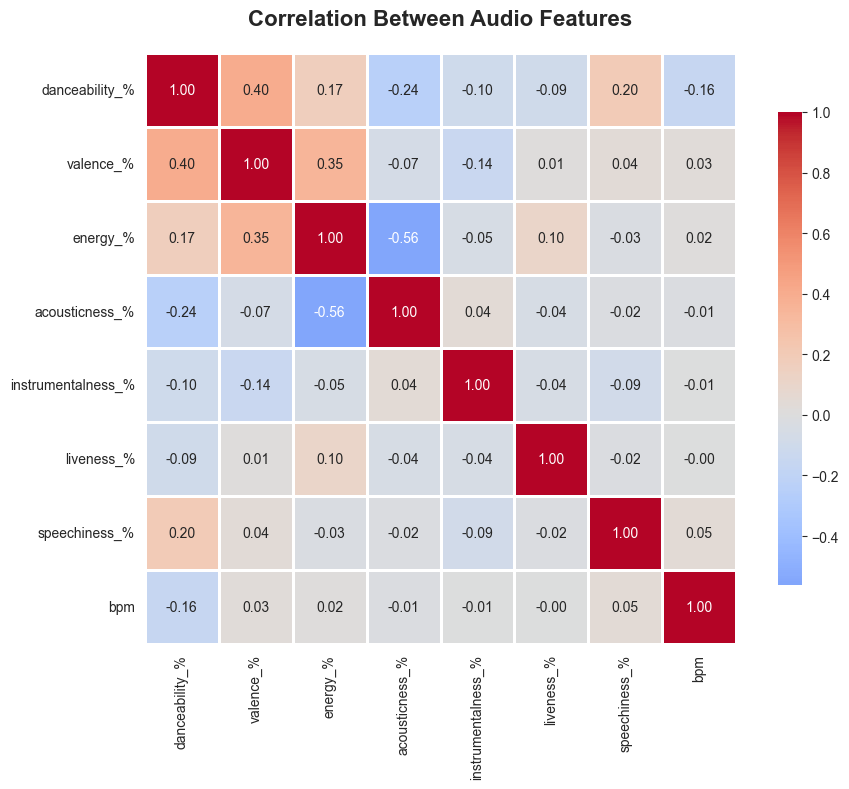

In [8]:
numeric_cols = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 
                'instrumentalness_%', 'liveness_%', 'speechiness_%', 'bpm']

correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Audio Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [9]:
import os
os.makedirs('../images', exist_ok=True)

print("Saving visualizations...")

fig1, ax1 = plt.subplots(figsize=(14, 8))
top_10 = df_clean.nlargest(10, 'streams')[['track_name', 'artist(s)_name', 'streams']]
ax1.barh(range(len(top_10)), top_10['streams'], color='steelblue')
ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels([f"{row['track_name']} - {row['artist(s)_name']}" for _, row in top_10.iterrows()])
ax1.set_xlabel('Streams', fontsize=12)
ax1.set_title('Top 10 Most Streamed Songs', fontsize=16, fontweight='bold')
ax1.invert_yaxis()
plt.tight_layout()
plt.savefig('../images/top_10_songs.png', dpi=300, bbox_inches='tight')
plt.close()

fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df_clean['danceability_%'], bins=30, color='coral', edgecolor='black')
axes[0, 0].set_title('Danceability Distribution', fontweight='bold')
axes[0, 1].hist(df_clean['energy_%'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Energy Distribution', fontweight='bold')
axes[1, 0].hist(df_clean['valence_%'], bins=30, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Valence Distribution', fontweight='bold')
axes[1, 1].hist(df_clean['bpm'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Tempo Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/audio_features_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

fig3, ax3 = plt.subplots(figsize=(12, 8))
scatter = ax3.scatter(df_clean['valence_%'], df_clean['energy_%'], 
                     c=df_clean['streams'], cmap='YlOrRd', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax3.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Valence (Happiness)', fontsize=14)
ax3.set_ylabel('Energy', fontsize=14)
ax3.set_title('Song Mood Map', fontsize=16, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Streams')
plt.tight_layout()
plt.savefig('../images/mood_map.png', dpi=300, bbox_inches='tight')
plt.close()

fig4, ax4 = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, ax=ax4,
            linewidths=1, cbar_kws={"shrink": 0.8})
ax4.set_title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ All visualizations saved to images/ folder!")

Saving visualizations...
✓ All visualizations saved to images/ folder!
